In [ ]:
%load_ext autoreload
%autoreload 2

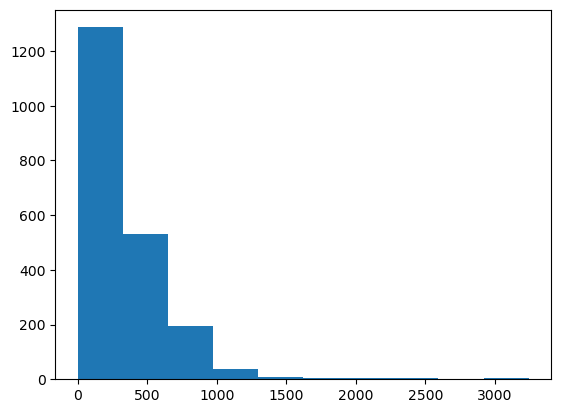

1442


In [1]:
import matplotlib.pyplot as plt
from astropy.table import Table
import numpy as np

bins = np.linspace(0,0.2e44,10)

catalog = Table.read("/data/hetdex/u/bgrashey/Katalog_updated.fits")
plt.hist(catalog["FWHM"])
plt.show()
LAE = (catalog["PROB"] > 0.4) & (catalog["FWHM"] < 1000) #& (catalog["FWHM"] > 0)

lae_cat = catalog[LAE]
print(len(lae_cat))

z_boundary = 2.8
density_boundary = 0.01
luminosity_boundary = 0.5e43

lum_high = lae_cat[lae_cat["LUMINOSITY"] > luminosity_boundary]
lum_low = lae_cat[lae_cat["LUMINOSITY"] < luminosity_boundary]

z_high = lae_cat[lae_cat["REDSHIFT"] > z_boundary]
z_low = lae_cat[lae_cat["REDSHIFT"] < z_boundary]

rho_high = lae_cat[lae_cat["DENSITY"] > density_boundary]
rho_low = lae_cat[lae_cat["DENSITY"] < density_boundary]

In [2]:
import zarr
from tools.stacking_revised import extract_all_subcubes
root = zarr.open_group("/data/hetdex/u/bgrashey/cubes/stack.zarr", mode="r")
cube = root["PRIMARY"]

subcubes = extract_all_subcubes(lae_cat, cube, width=55, spec_width=40)

/data/backup/hetdex/u/bgrashey/envs/cube_aktuell/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Subcubes extrahiert: 1321 (Ausserhalb/Skipped: 121)


In [ ]:
for i in range(len(subcubes)):
    nb = np.nanmean(subcubes[i]["subcube"], axis=0)
    plt.imshow(nb)
    plt.show()

In [3]:
def save_subcubes_npz(subcube_list, filename="subcubes_extracted.npz"):
    data_dict = {"n_items": len(subcube_list)}
    
    for i, item in enumerate(subcube_list):
        data_dict[f"cube_{i}"] = item["subcube"]
        data_dict[f"wcs_hdr_{i}"] = item["wcs"].to_header_string()
        data_dict[f"ra_{i}"] = item["ra"]
        data_dict[f"dec_{i}"] = item["dec"]
        data_dict[f"z_{i}"] = item["z"]
        data_dict[f"lum_{i}"] = item["lum"]
        
        # Maske mitspeichern (falls schon vorhanden, sonst None)
        if "mask" in item and item["mask"] is not None:
            data_dict[f"mask_{i}"] = item["mask"]

    np.savez(filename, **data_dict)
    print(f"Erfolgreich gespeichert in: {filename}")

# Ausführen:
save_subcubes_npz(subcubes, "/data/hetdex/u/bgrashey/data/subcubes_for_laptop.npz")

Erfolgreich gespeichert in: /data/hetdex/u/bgrashey/data/subcubes_for_laptop.npz


In [ ]:
import zarr
from tools.stacking_revised import Stacking

root = zarr.open_group("/data/hetdex/u/bgrashey/cubes/stack.zarr", mode="r")
cube = root["PRIMARY"]

stacked = Stacking(lae_cat, cube, width=30 , spec_width=50, kpc_pxl=1, npix=30)

In [ ]:
img = stacked.stack(do_sky_sub=False, do_cont_sub=False, normalize=False)

In [ ]:
img.shape

In [ ]:
for n in range(img.shape[0]):
    plt.imshow(img[n, :, :])
    plt.show()

In [ ]:
img_2d = stacked.narrowband_from_cube(half_width=15, mode="median")
psf = stacked.stack_psf()

plt.imshow(img_2d)
plt.show()

In [ ]:
radi, fluxes, err = stacked.extract_sb_profile(img_2d, center=(15,15), r_max=30)
_, psf_values, _ = stacked.extract_sb_profile(psf, r_max=30)

psf_sb_norm = psf_values * (fluxes[0] / psf_values[0])

plt.plot(radi, fluxes*1e-17, label="flux")
plt.plot(radi, psf_sb_norm*1e-17, label="PSF")
plt.tight_layout()
plt.xlabel("r [pkpc]")
plt.ylabel("SBe [1e-17 erg/s/cm²/Å/arcsec²]")
plt.yscale("log")
plt.legend()
plt.show()

In [ ]:
stacked_lum_high = Stacking(lum_high, cube, kpc_pxl=1, npix=30)
img_lum_high = stacked_lum_high.stack()

In [ ]:
stacked_lum_low = Stacking(lum_low, cube, kpc_pxl=1, npix=30)
img_lum_low = stacked_lum_low.stack()

In [ ]:
img_2d_lum_low = stacked_lum_low.narrowband_from_cube()
img_2d_lum_high = stacked_lum_high.narrowband_from_cube()

In [ ]:
_, fluxes_lum_low, _ = stacked.cog(img_2d_lum_low, r_max=30)
_, fluxes_lum_high, _ = stacked.cog(img_2d_lum_high, r_max=30)

#plt.plot(radi, fluxes, label="flux")
plt.plot(radi, fluxes_lum_low, label="lum_low")
plt.plot(radi, fluxes_lum_high, label="lum_high")
plt.tight_layout()
plt.xlabel("r [pkpc]")
plt.ylabel("SBe [1e-17 erg/s/cm²/Å/arcsec²]")
plt.legend()
plt.show()

In [ ]:
stacked_z_high = Stacking(z_high, cube, kpc_pxl=1, npix=30)
img_z_high = stacked_z_high.stack()

In [ ]:
stacked_z_low = Stacking(z_low, cube, kpc_pxl=1, npix=30)
img_z_low = stacked_z_low.stack()

In [ ]:
img_2d_z_low = stacked_z_low.narrowband_from_cube()
img_2d_z_high = stacked_z_high.narrowband_from_cube()

In [ ]:
_, fluxes_z_low, _ = stacked.cog(img_2d_z_low, r_max=30)
_, fluxes_z_high, _ = stacked.cog(img_2d_z_high, r_max=30)

#plt.plot(radi, fluxes, label="flux")
plt.plot(radi, fluxes_z_low, label="z_low")
plt.plot(radi, fluxes_z_high, label="z_high")
plt.tight_layout()
plt.xlabel("r [pkpc]")
plt.ylabel("SBe [1e-17 erg/s/cm²/Å/arcsec²]")
plt.legend()
plt.show()

In [ ]:
#stacked_rho_low = Stacking(rho_low, cube, kpc_pxl=0.5, npix=200)
#img_rho_low = stacked_rho_low.stack()

In [ ]:
#stacked_rho_high = Stacking(rho_high, cube, kpc_pxl=0.5, npix=200)
#img_rho_high = stacked_rho_high.stack()

In [ ]:
#img_2d_z_low = stacked_z_low.narrowband_from_cube()
#img_2d_z_high = stacked_z_high.narrowband_from_cube()

#img_2d_rho_low = stacked_rho_low.narrowband_from_cube()
#img_2d_rho_high = stacked_rho_high.narrowband_from_cube()

In [ ]:
from tools.stacking_revised import StackingFromSubcubes, load_subcubes_npz 
import matplotlib.pyplot as plt

In [ ]:
subcubes = load_subcubes_npz("/data/hetdex/u/bgrashey/data/subcubes_checked.npz")

In [ ]:
stacker = StackingFromSubcubes(subcubes, kpc_pxl=2, npix=100)

stacked_cube = stacker.stack(
    do_sky_sub=False,
    do_cont_sub=False,
    normalize=False
)

stacked_nb = stacker.narrowband_from_cube(half_width=15, mode="sum")

In [ ]:
plt.imshow(stacked_nb, origin="lower")
plt.xlabel("Pxl")
plt.ylabel("Pxl")
plt.show()

In [ ]:
r_kpc, sb, sb_err = stacker.extract_sb_profile(
    stacked_nb,
    kpc_per_px=stacker.kpc_pxl, 
    r_max=50, 
    n_bins=10
)

plt.plot(r_kpc, sb*1e-17)
plt.yscale("log")
plt.ylabel("SBe [erg/s/cm^2/arcsec^2]")
plt.xlabel("r [pkpc]")
plt.show()